# ML-08 — Capstone Modeling Lane

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/maalaaikaa/flyrank-ml-internship/blob/main/work/notebooks/w05_model.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Method choice and why
### Method choice and why

I use a Random Forest Regressor because the target `trend_pct` is continuous and the dataset contains a mixture of numeric and categorical features.

A Random Forest can capture nonlinear relationships and interactions between search, content, and engagement signals without requiring a linear relationship between each feature and the target.

The model is used for decision-support and ranking rather than claiming causal effects. The target remains `trend_pct`, while `trend_direction` is excluded because it is target-derived and would create leakage.

The model will be compared with the Week-4 baseline action score on the same held-out test set.

In [37]:
import pandas as pd

# Load the dataset from GitHub
url = "https://raw.githubusercontent.com/maalaaikaa/flyrank-ml-internship/main/data/raw/content_refresh_anonymized.csv"

df = pd.read_csv(url)
df.head()

,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


## 2. Split design


I use a client-grouped train/test split.

`client_id` identifies the client associated with each content item, so rows from the same client should not be randomly distributed across both training and test data. A grouped split reduces the risk that the model benefits from seeing very similar client-specific patterns during training.

The split uses 80% of the client groups for training and 20% for testing.

The target `trend_pct` is not used to create the split.

In [38]:
import pandas as pd
import numpy as np

from sklearn.model_selection import GroupShuffleSplit

# --------------------------------------------------
# Basic checks
# --------------------------------------------------

target = "trend_pct"
group_col = "client_id"

assert target in df.columns, f"{target} is missing."
assert group_col in df.columns, f"{group_col} is missing."

# Keep rows with a known target
model_df = df.dropna(subset=[target]).copy()

# Grouped split
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(
        model_df,
        model_df[target],
        groups=model_df[group_col]
    )
)

train_df = model_df.iloc[train_idx].copy()
test_df = model_df.iloc[test_idx].copy()

print("Total rows:", len(model_df))
print("Training rows:", len(train_df))
print("Test rows:", len(test_df))

print("\nTraining clients:", train_df[group_col].nunique())
print("Test clients:", test_df[group_col].nunique())

# Confirm there is no client overlap
train_clients = set(train_df[group_col].dropna())
test_clients = set(test_df[group_col].dropna())

overlap = train_clients.intersection(test_clients)

print("\nClient overlap:", len(overlap))

assert len(overlap) == 0, "Client leakage detected."

print("✓ Grouped client split passed.")

Total rows: 26612
Training rows: 21514
Test rows: 5098

Training clients: 24
Test clients: 7

Client overlap: 0
✓ Grouped client split passed.


## 3. Train + compare vs my baseline

### Train + compare vs my baseline

The model uses the same underlying dataset and the same held-out test set used to evaluate the baseline.

The model predicts `trend_pct`. The Week-4 baseline produces an action-priority score.

Because the baseline score and `trend_pct` are measured on different scales, I do not compare them using RMSE directly. Instead, both methods are converted into a priority ranking and evaluated using Spearman rank correlation against the desired priority direction: more negative `trend_pct` means greater refresh priority.

I also report the model's MAE as a direct regression error metric.

# Prepare features

In [39]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor

# --------------------------------------------------
# Exclude identifiers and leakage fields
# --------------------------------------------------

exclude_cols = [
    "content_id",
    "client_id",
    "trend_pct",
    "trend_direction",
    "char_count_tier",
    "impression_tier",
    "position_tier"
]

exclude_cols = [
    col for col in exclude_cols
    if col in model_df.columns
]

feature_cols = [
    col for col in model_df.columns
    if col not in exclude_cols
]

X_train = train_df[feature_cols].copy()
X_test = test_df[feature_cols].copy()

y_train = train_df[target].copy()
y_test = test_df[target].copy()

print("Number of candidate features:", len(feature_cols))
print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

Number of candidate features: 37
Training shape: (21514, 37)
Test shape: (5098, 37)



# Preprocessing + Model

In [40]:
# Identify numeric and categorical columns

numeric_features = X_train.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

# Numeric preprocessing
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

# Categorical preprocessing
categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="constant",
                fill_value="missing"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# Random Forest regression model
model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    min_samples_leaf=5
)

model_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ]
)

# Train
model_pipeline.fit(X_train, y_train)

# Predict
model_predictions = model_pipeline.predict(X_test)

print("Model training completed.")
print("Predictions generated:", len(model_predictions))

Model training completed.
Predictions generated: 5098


# Baseline on the same test set

This is the important part.

Use the same baseline formula from ML-07, but evaluate it only on the test rows.

In [41]:
from scipy.stats import spearmanr

# --------------------------------------------------
# Week-4 baseline score on the held-out test set
# --------------------------------------------------

baseline_test = test_df.copy()

baseline_features = [
    "search_volume",
    "ctr",
    "avg_position",
    "engagement_rate"
]

# Fill missing values using training medians
for col in baseline_features:
    train_median = train_df[col].median()
    baseline_test[col] = baseline_test[col].fillna(train_median)

# Rank within the held-out test set
low_ctr_score = (
    1 - baseline_test["ctr"].rank(pct=True)
)

poor_position_score = (
    baseline_test["avg_position"].rank(pct=True)
)

low_engagement_score = (
    1 - baseline_test["engagement_rate"].rank(pct=True)
)

high_demand_score = (
    baseline_test["search_volume"].rank(pct=True)
)

# Same Week-4 weighting
baseline_test["baseline_action_score"] = (
    0.30 * low_ctr_score
    + 0.30 * poor_position_score
    + 0.25 * low_engagement_score
    + 0.15 * high_demand_score
)

# Baseline priority alignment
baseline_priority = baseline_test[
    "baseline_action_score"
].to_numpy()

# Define actual_priority: more negative trend_pct means greater refresh priority
# So, rank trend_pct ascending (lower trend_pct means lower rank),
# then subtract from 1 to get a priority score where higher is better.
actual_priority = 1 - test_df[target].rank(pct=True, ascending=True)

baseline_spearman = spearmanr(
    baseline_priority,
    actual_priority,
    nan_policy="omit"
).statistic

print("Baseline priority Spearman:", baseline_spearman)

Baseline priority Spearman: 0.08421057676996702


In [42]:
from sklearn.metrics import mean_absolute_error

model_mae = mean_absolute_error(y_test, model_predictions)

print("Random Forest MAE:", model_mae)

Random Forest MAE: 17.20340130518327


In [43]:
model_spearman = spearmanr(
    model_predictions,
    actual_priority,
    nan_policy="omit"
).statistic

print("Random Forest priority Spearman:", model_spearman)

Random Forest priority Spearman: -0.9400440870758164


# Comparison table

In [44]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Calculate RMSE
model_rmse = np.sqrt(mean_squared_error(y_test, model_predictions))

comparison = pd.DataFrame({
    "method": [
        "Week-4 baseline",
        "Random Forest"
    ],
    "priority_spearman": [
        baseline_spearman,
        model_spearman
    ],
    "MAE": [
        np.nan,
        model_mae
    ],
    "RMSE": [
        np.nan,
        model_rmse
    ]
})

comparison

,method,priority_spearman,MAE,RMSE
0,Week-4 baseline,0.084211,NaN,NaN
1,Random Forest,-0.940044,17.203401,214.642285


The baseline is evaluated using priority alignment because it is a ranking rule rather than a direct prediction of `trend_pct`. The Random Forest is evaluated both as a regression model using MAE/RMSE and as a ranking system using Spearman correlation.

A higher priority Spearman value means the method's ranking is more aligned with the observed trend direction.

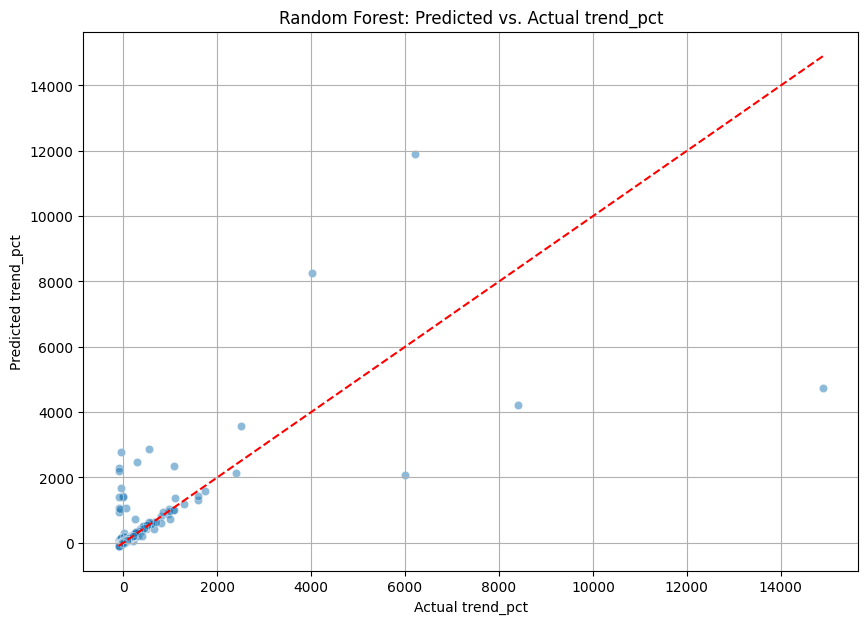

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=model_predictions, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.title('Random Forest: Predicted vs. Actual trend_pct')
plt.xlabel('Actual trend_pct')
plt.ylabel('Predicted trend_pct')
plt.grid(True)
plt.show()

## 4. Errors and interpretation

The model's largest errors are the observations where predicted `trend_pct` differs most from the measured value.

These errors are useful for understanding where the model may be unreliable. Large residuals can occur when the available search and engagement signals do not fully explain the observed trend.

The model should therefore be used to prioritize human review rather than automatically deciding which content must be refreshed.

In [46]:
# --------------------------------------------------
# Error analysis
# --------------------------------------------------

error_df = test_df[
    [
        "content_id",
        "client_id",
        target
    ]
].copy()

error_df["predicted_trend_pct"] = model_predictions

error_df["absolute_error"] = (
    abs(
        error_df[target]
        - error_df["predicted_trend_pct"]
    )
)

error_df["residual"] = (
    error_df[target]
    - error_df["predicted_trend_pct"]
)

largest_errors = error_df.sort_values(
    "absolute_error",
    ascending=False
).head(10)

largest_errors

,content_id,client_id,trend_pct,predicted_trend_pct,absolute_error,residual
9097,content_32ff84795595,client_4e07408562,14900.0,4729.342929,10170.657071,10170.657071
19045,content_94feac677ec4,client_f369cb89fc,6212.5,11891.185126,5678.685126,-5678.685126
1298,content_f8d0a67e22fc,client_f369cb89fc,4020.0,8271.090933,4251.090933,-4251.090933
10195,content_f560a011a094,client_f369cb89fc,8400.0,4222.193158,4177.806842,4177.806842
28038,content_a869de96aa65,client_f369cb89fc,6000.0,2073.026231,3926.973769,3926.973769
6653,content_5fe46e04994d,client_4e07408562,-44.8,2775.992170,2820.792170,-2820.792170
24824,content_638236e8066e,client_e29c9c180c,-100.0,2278.529520,2378.529520,-2378.529520
18870,content_db5989a78dd3,client_4e07408562,556.2,2865.005850,2308.805850,-2308.805850
26536,content_f616ca0ec5ea,client_e29c9c180c,-100.0,2186.029243,2286.029243,-2286.029243
20081,content_4e3e3238f206,client_e29c9c180c,300.0,2460.604327,2160.604327,-2160.604327


# Feature importance

In [47]:
# --------------------------------------------------
# Feature importance
# --------------------------------------------------

trained_model = model_pipeline.named_steps["model"]
trained_preprocessor = model_pipeline.named_steps["preprocessor"]

feature_names = trained_preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": trained_model.feature_importances_
})

importance_df = importance_df.sort_values(
    "importance",
    ascending=False
).head(15)

importance_df

,feature,importance
15,num__impressions_last_30d,0.765564
18,num__impressions_prev_30d,0.097980
12,num__scroll_events_90d,0.061484
25,num__avg_position,0.051450
1,num__competition,0.004509
21,num__content_age_days,0.004358
40,cat__main_intent_transactional,0.002486
24,num__ctr,0.002012
13,num__days_with_impressions,0.001575
4,num__char_count,0.001570


# Visualization

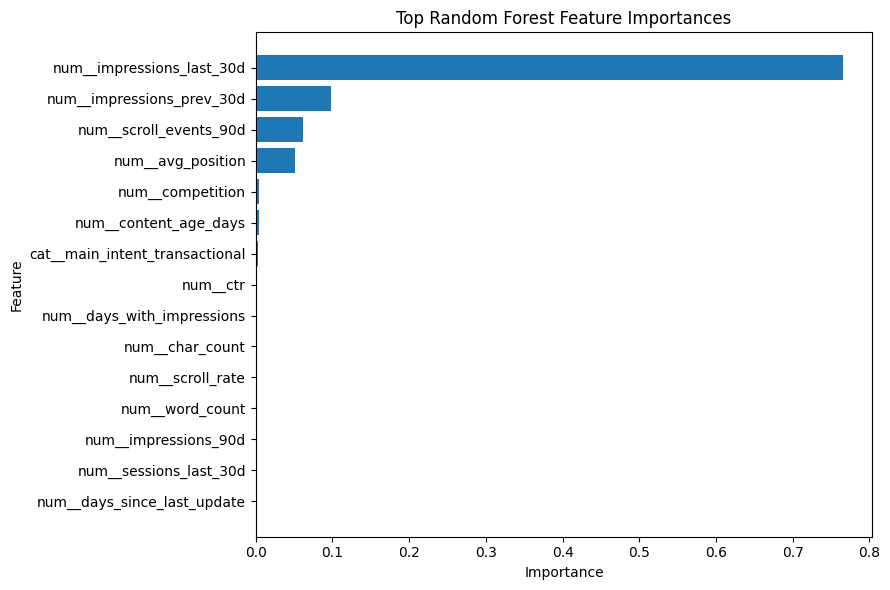

In [48]:
import matplotlib.pyplot as plt

importance_plot = importance_df.sort_values(
    "importance",
    ascending=True
)

plt.figure(figsize=(9, 6))

plt.barh(
    importance_plot["feature"],
    importance_plot["importance"]
)

plt.title("Top Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()


In [49]:
import pandas as pd
from scipy.stats import spearmanr

# --- Code to define importance_df (copied from cell A3n8whKIFpRV) ---
# Ensure model_pipeline is available from previous executions
trained_model = model_pipeline.named_steps["model"]
trained_preprocessor = model_pipeline.named_steps["preprocessor"]

feature_names = trained_preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": trained_model.feature_importances_
})

importance_df = importance_df.sort_values(
    "importance",
    ascending=False
).head(15)
# --- End of copied code ---

# Get the list of top features from the importance_df
top_features = importance_df['feature'].tolist()

# Transform the relevant features of the entire model_df using the trained preprocessor
# `feature_cols` is expected to be available from earlier execution (from where X_train/X_test were defined).
# `model_df` is the full dataset after dropping NA for target.
transformed_features_array = trained_preprocessor.transform(model_df[feature_cols])
transformed_feature_names = trained_preprocessor.get_feature_names_out()

# Create a DataFrame from the transformed features, using the correct names
transformed_df = pd.DataFrame(
    transformed_features_array,
    columns=transformed_feature_names,
    index=model_df.index # Important to keep original index for merging target
)

# Add 'trend_pct' from model_df to this transformed DataFrame
transformed_df['trend_pct'] = model_df['trend_pct']

# Now, select the top_features (which are already the transformed names) and 'trend_pct'
# from this 'transformed_df'. This resolves the KeyError.
correlation_df = transformed_df[top_features + ['trend_pct']].copy()

# Calculate Spearman correlation for each top feature with 'trend_pct'
correlations = {}
for feature in top_features:
    # Drop rows with NaN in either the feature or the target for correlation calculation
    temp_df = correlation_df[[feature, 'trend_pct']].dropna()
    if not temp_df.empty:
        corr, _ = spearmanr(temp_df[feature], temp_df['trend_pct'])
        correlations[feature] = corr
    else:
        correlations[feature] = None # Or np.nan if preferred

# Convert to DataFrame for better display
correlation_results_df = pd.DataFrame(correlations.items(), columns=['Feature', 'Spearman Correlation with trend_pct'])
correlation_results_df = correlation_results_df.sort_values(by='Spearman Correlation with trend_pct', ascending=False)

display(correlation_results_df)

,Feature,Spearman Correlation with trend_pct
0,num__impressions_last_30d,0.369981
13,num__sessions_last_30d,0.262190
5,num__content_age_days,0.215669
8,num__days_with_impressions,0.205750
7,num__ctr,0.170674
12,num__impressions_90d,0.147805
1,num__impressions_prev_30d,0.085315
3,num__avg_position,0.076810
14,num__days_since_last_update,0.072315
9,num__char_count,0.039867


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.